In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, matthews_corrcoef, roc_auc_score)

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier # <-- NEW IMPORT

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
# Load the dataset exactly as you did in your original working file
df = pd.read_csv('heart_disease.csv')

# Setup Features and Target
X = df.drop(columns=['target'])
y = df['target']

# Isolate continuous features for noise injection
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

def add_awgn_noise(data, noise_level, continuous_cols):
    """Injects AWGN based on the standard deviation of each continuous column."""
    noisy_data = data.copy()
    if noise_level > 0:
        for col in continuous_cols:
            std_dev = data[col].std()
            noise = np.random.normal(0, noise_level * std_dev, size=data.shape[0])
            noisy_data[col] = noisy_data[col] + noise
    return noisy_data

In [28]:
# ---------------------------------------------------------
# EDA PART 1: Detailed Tabular Analysis
# ---------------------------------------------------------
print("1. Dataset Overview (First 5 Rows):")
display(df.head())

print("\n2. Statistical Summary of Continuous Features:")
# .T transposes the table to make it easier to read
display(df[continuous_cols].describe().T)

print("\n3. Missing Values Check:")
missing_vals = df.isnull().sum().to_frame(name='Missing Values')
display(missing_vals[missing_vals['Missing Values'] > 0] if missing_vals.sum().values[0] > 0 else "No missing values found!")

print("\n4. Target Variable Distribution (Class Balance):")
target_dist = df['target'].value_counts().to_frame(name='Count')
target_dist['Percentage (%)'] = (df['target'].value_counts(normalize=True) * 100).round(2)
display(target_dist)

1. Dataset Overview (First 5 Rows):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



2. Statistical Summary of Continuous Features:


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2



3. Missing Values Check:


'No missing values found!'


4. Target Variable Distribution (Class Balance):


,Count,Percentage (%)
target,,
1,526,51.32
0,499,48.68


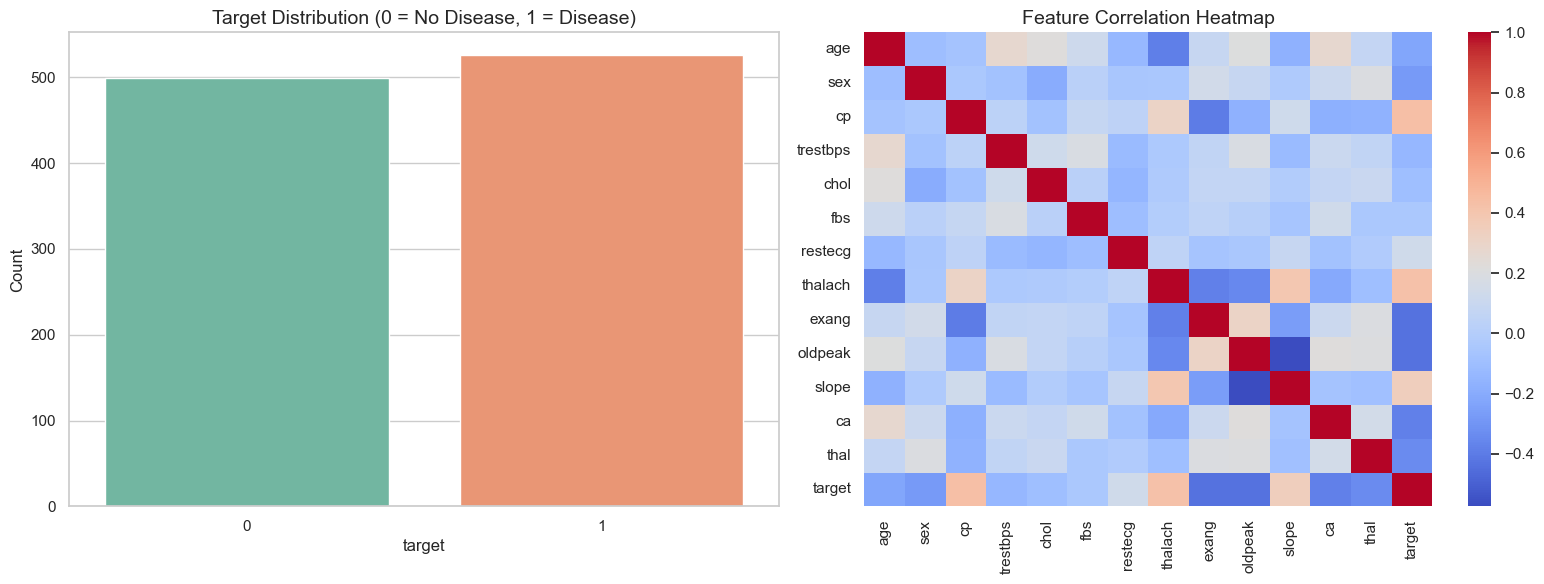

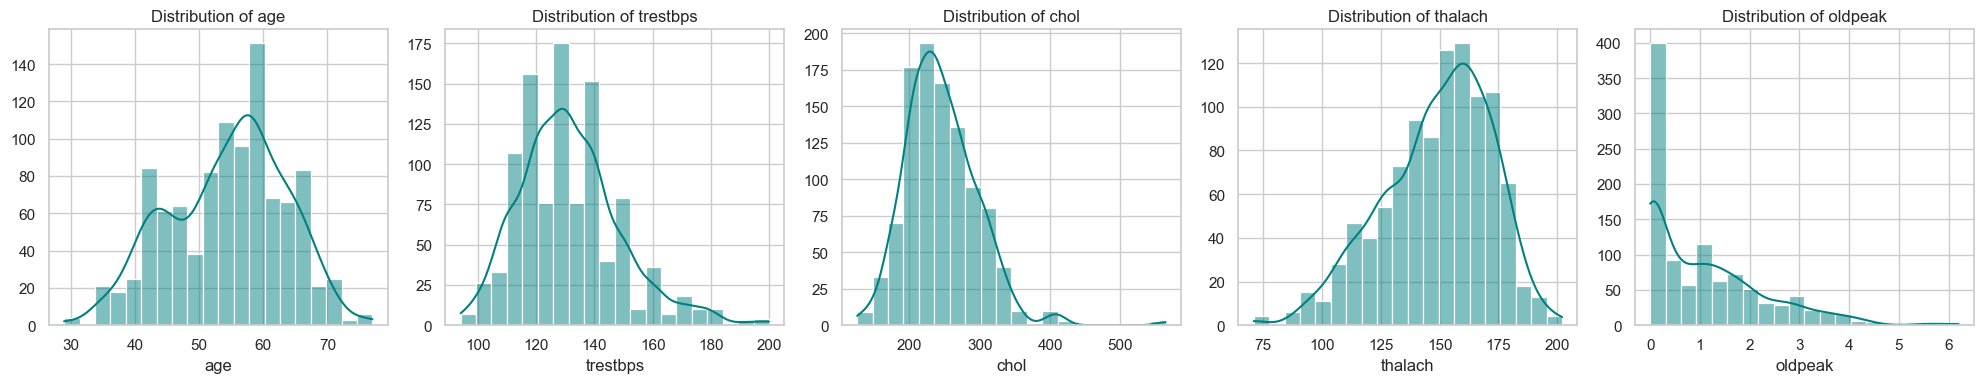

In [29]:
# ---------------------------------------------------------
# EDA PART 2: Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Target Distribution (Bar Chart)
sns.countplot(data=df, x='target', palette='Set2', ax=axes[0])
axes[0].set_title('Target Distribution (0 = No Disease, 1 = Disease)', fontsize=14)
axes[0].set_ylabel('Count')

# Plot 2: Correlation Heatmap
# This shows how strongly features correlate with each other and the target
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

# Plot 3: Distributions of Continuous Features (with KDE curves)
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(20, 4))
for idx, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='teal', bins=20)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_ylabel('')
    
plt.tight_layout()
plt.show()

In [30]:
# Experiment Configurations
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5] # 0% to 50%
iterations = 5 

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'MLP': MLPClassifier(random_state=42, max_iter=500)
}

def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

results = []
print("Running Iterative Degradation Experiment...")

for i in range(iterations):
    seed = 42 + i
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)
    
    scaler = StandardScaler()
    X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])
    
    for noise in noise_levels:
        X_train_noisy = add_awgn_noise(X_train, noise, continuous_cols)
        X_test_noisy = add_awgn_noise(X_test, noise, continuous_cols)
        
        for model_name, model in models.items():
            
            # --- Scenario A: Train Noisy, Test Pristine ---
            model.fit(X_train_noisy, y_train)
            preds_A = model.predict(X_test)
            probs_A = model.predict_proba(X_test)[:, 1] 
            
            metrics_A = get_metrics(y_test, preds_A, probs_A)
            row_A = {
                'Iteration': i+1, 'Model': model_name, 'Scenario': 'Train Noisy / Test Pristine',
                'Noise Level': int(noise * 100)
            }
            row_A.update(metrics_A)
            results.append(row_A)
            
            # --- Scenario B: Train Pristine, Test Noisy ---
            model.fit(X_train, y_train)
            preds_B = model.predict(X_test_noisy)
            probs_B = model.predict_proba(X_test_noisy)[:, 1]
            
            metrics_B = get_metrics(y_test, preds_B, probs_B)
            row_B = {
                'Iteration': i+1, 'Model': model_name, 'Scenario': 'Train Pristine / Test Noisy',
                'Noise Level': int(noise * 100)
            }
            row_B.update(metrics_B)
            results.append(row_B)

# 1. Average results across iterations
results_df = pd.DataFrame(results)
agg_results = results_df.drop(columns=['Iteration']).groupby(['Model', 'Scenario', 'Noise Level']).mean().reset_index()

# 2. Calculate Performance Decay Rates for F1, MCC, and AUC-ROC
baseline_f1 = agg_results[agg_results['Noise Level'] == 0].set_index(['Model', 'Scenario'])['F1-Score']
baseline_mcc = agg_results[agg_results['Noise Level'] == 0].set_index(['Model', 'Scenario'])['MCC']
baseline_auc = agg_results[agg_results['Noise Level'] == 0].set_index(['Model', 'Scenario'])['AUC-ROC']

def calculate_decay(row, baseline_series, metric_name):
    base_val = baseline_series.loc[(row['Model'], row['Scenario'])]
    if base_val <= 0: return 0 # Prevent division by zero or negative baseline inflation
    decay = ((base_val - row[metric_name]) / base_val) * 100
    return max(0, decay) 

agg_results['Decay Rate (F1) (%)'] = agg_results.apply(lambda r: calculate_decay(r, baseline_f1, 'F1-Score'), axis=1)
agg_results['Decay Rate (MCC) (%)'] = agg_results.apply(lambda r: calculate_decay(r, baseline_mcc, 'MCC'), axis=1)
agg_results['Decay Rate (AUC-ROC) (%)'] = agg_results.apply(lambda r: calculate_decay(r, baseline_auc, 'AUC-ROC'), axis=1)

print("Experiment Complete! Calculated Decay Rates for F1, MCC, and AUC-ROC.")

Running Iterative Degradation Experiment...
Experiment Complete! Calculated Decay Rates for F1, MCC, and AUC-ROC.


In [31]:
formatted_table = agg_results.copy()
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 'AUC-ROC']
formatted_table[metric_cols] = formatted_table[metric_cols].round(4)

decay_cols = ['Decay Rate (F1) (%)', 'Decay Rate (MCC) (%)', 'Decay Rate (AUC-ROC) (%)']
formatted_table[decay_cols] = formatted_table[decay_cols].round(2)

print("\n--- Detailed Evaluation Metrics (Averaged over 5 iterations) ---")
for scenario in formatted_table['Scenario'].unique():
    print(f"\nScenario: {scenario}")
    scenario_data = formatted_table[formatted_table['Scenario'] == scenario].drop(columns=['Scenario'])
    display(scenario_data)

agg_results.to_csv("robustness_metrics_full.csv", index=False)


--- Detailed Evaluation Metrics (Averaged over 5 iterations) ---

Scenario: Train Noisy / Test Pristine


,Model,Noise Level,Accuracy,Precision,Recall,F1-Score,MCC,AUC-ROC,Decay Rate (F1) (%),Decay Rate (MCC) (%),Decay Rate (AUC-ROC) (%)
0,MLP,0,0.9825,0.9814,0.9846,0.9828,0.9652,0.9936,0.00,0.00,0.00
1,MLP,10,0.9766,0.9768,0.9781,0.9771,0.9537,0.9930,0.58,1.19,0.06
2,MLP,20,0.9714,0.9724,0.9722,0.9722,0.9430,0.9941,1.08,2.31,0.00
3,MLP,30,0.9643,0.9698,0.9608,0.9651,0.9287,0.9914,1.80,3.79,0.22
4,MLP,40,0.9494,0.9419,0.9607,0.9510,0.8990,0.9883,3.24,6.86,0.53
5,MLP,50,0.9455,0.9436,0.9514,0.9472,0.8912,0.9856,3.62,7.67,0.80
12,Random Forest,0,0.9922,0.9925,0.9919,0.9921,0.9846,0.9998,0.00,0.00,0.00
13,Random Forest,10,0.9812,0.9823,0.9809,0.9815,0.9624,0.9981,1.06,2.26,0.17
14,Random Forest,20,0.9714,0.9671,0.9769,0.9719,0.9428,0.9943,2.03,4.24,0.54
15,Random Forest,30,0.9552,0.9460,0.9681,0.9568,0.9107,0.9905,3.56,7.51,0.93



Scenario: Train Pristine / Test Noisy


,Model,Noise Level,Accuracy,Precision,Recall,F1-Score,MCC,AUC-ROC,Decay Rate (F1) (%),Decay Rate (MCC) (%),Decay Rate (AUC-ROC) (%)
6,MLP,0,0.9825,0.9814,0.9846,0.9828,0.9652,0.9936,0.00,0.00,0.00
7,MLP,10,0.9792,0.9775,0.9820,0.9795,0.9588,0.9927,0.34,0.66,0.09
8,MLP,20,0.9669,0.9734,0.9621,0.9675,0.9340,0.9914,1.56,3.23,0.22
9,MLP,30,0.9526,0.9529,0.9540,0.9534,0.9051,0.9871,3.00,6.23,0.65
10,MLP,40,0.9318,0.9335,0.9327,0.9328,0.8638,0.9817,5.09,10.51,1.20
11,MLP,50,0.9123,0.9129,0.9161,0.9143,0.8245,0.9730,6.97,14.58,2.07
18,Random Forest,0,0.9922,0.9925,0.9919,0.9921,0.9846,0.9998,0.00,0.00,0.00
19,Random Forest,10,0.9844,0.9846,0.9845,0.9845,0.9688,0.9991,0.76,1.60,0.07
20,Random Forest,20,0.9669,0.9610,0.9744,0.9676,0.9339,0.9954,2.47,5.15,0.43
21,Random Forest,30,0.9513,0.9448,0.9605,0.9525,0.9026,0.9905,3.99,8.33,0.93


Generating Dashboards...


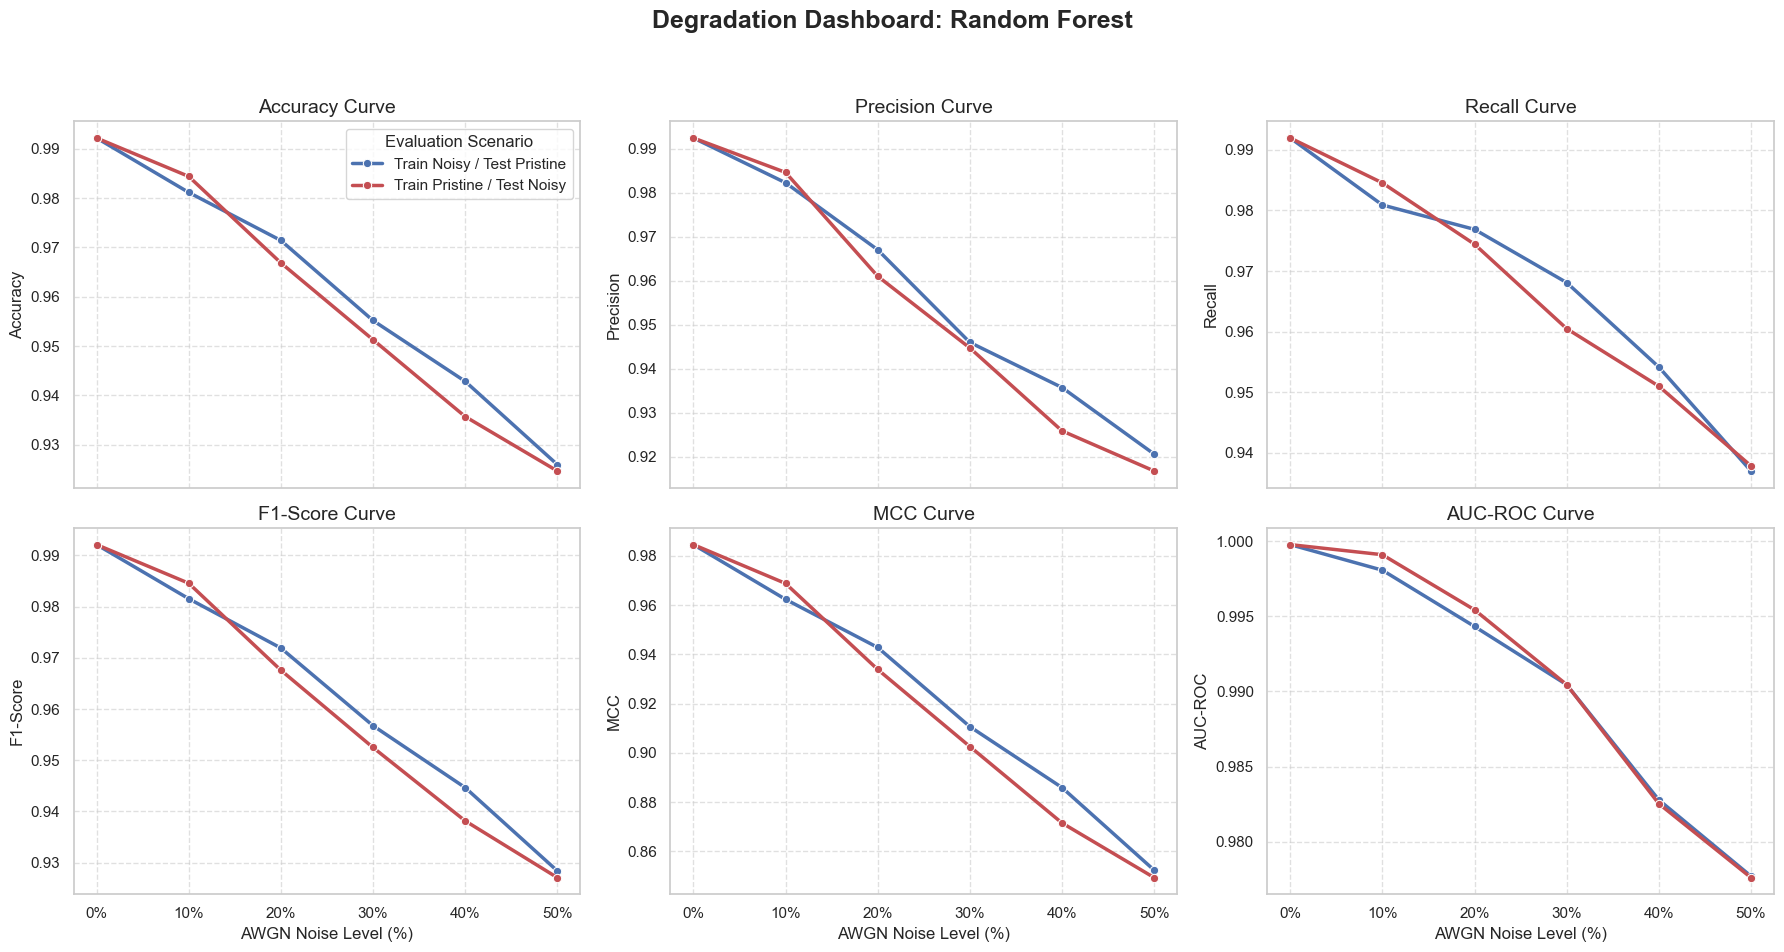

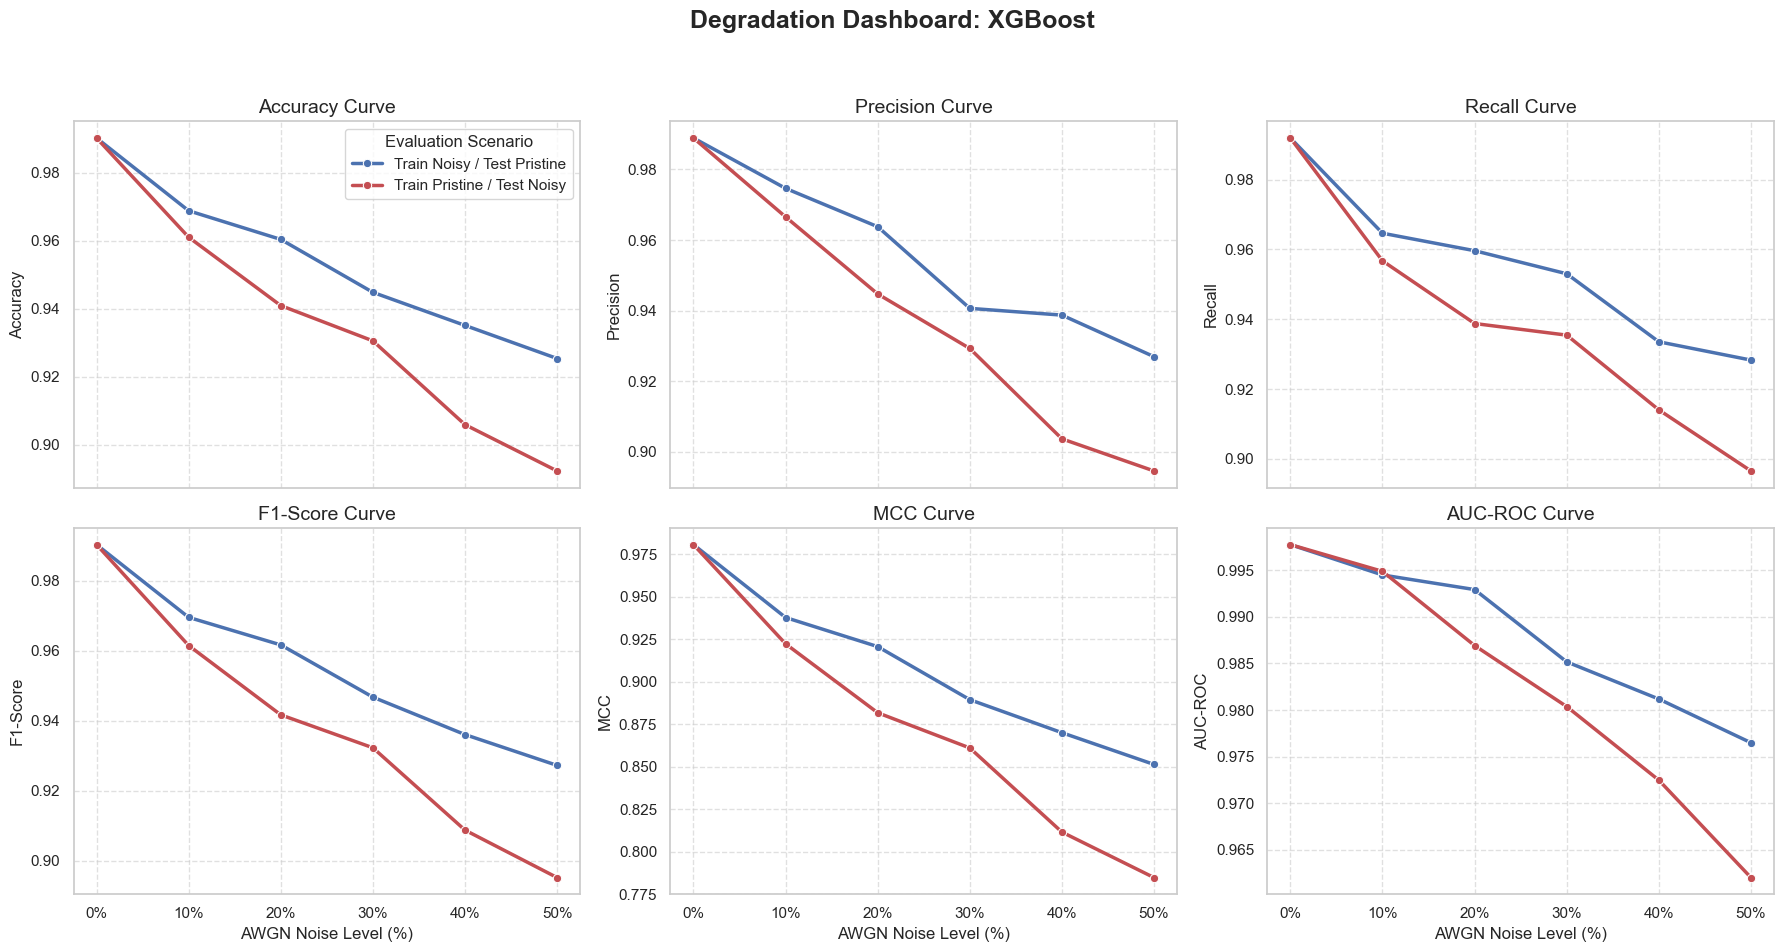

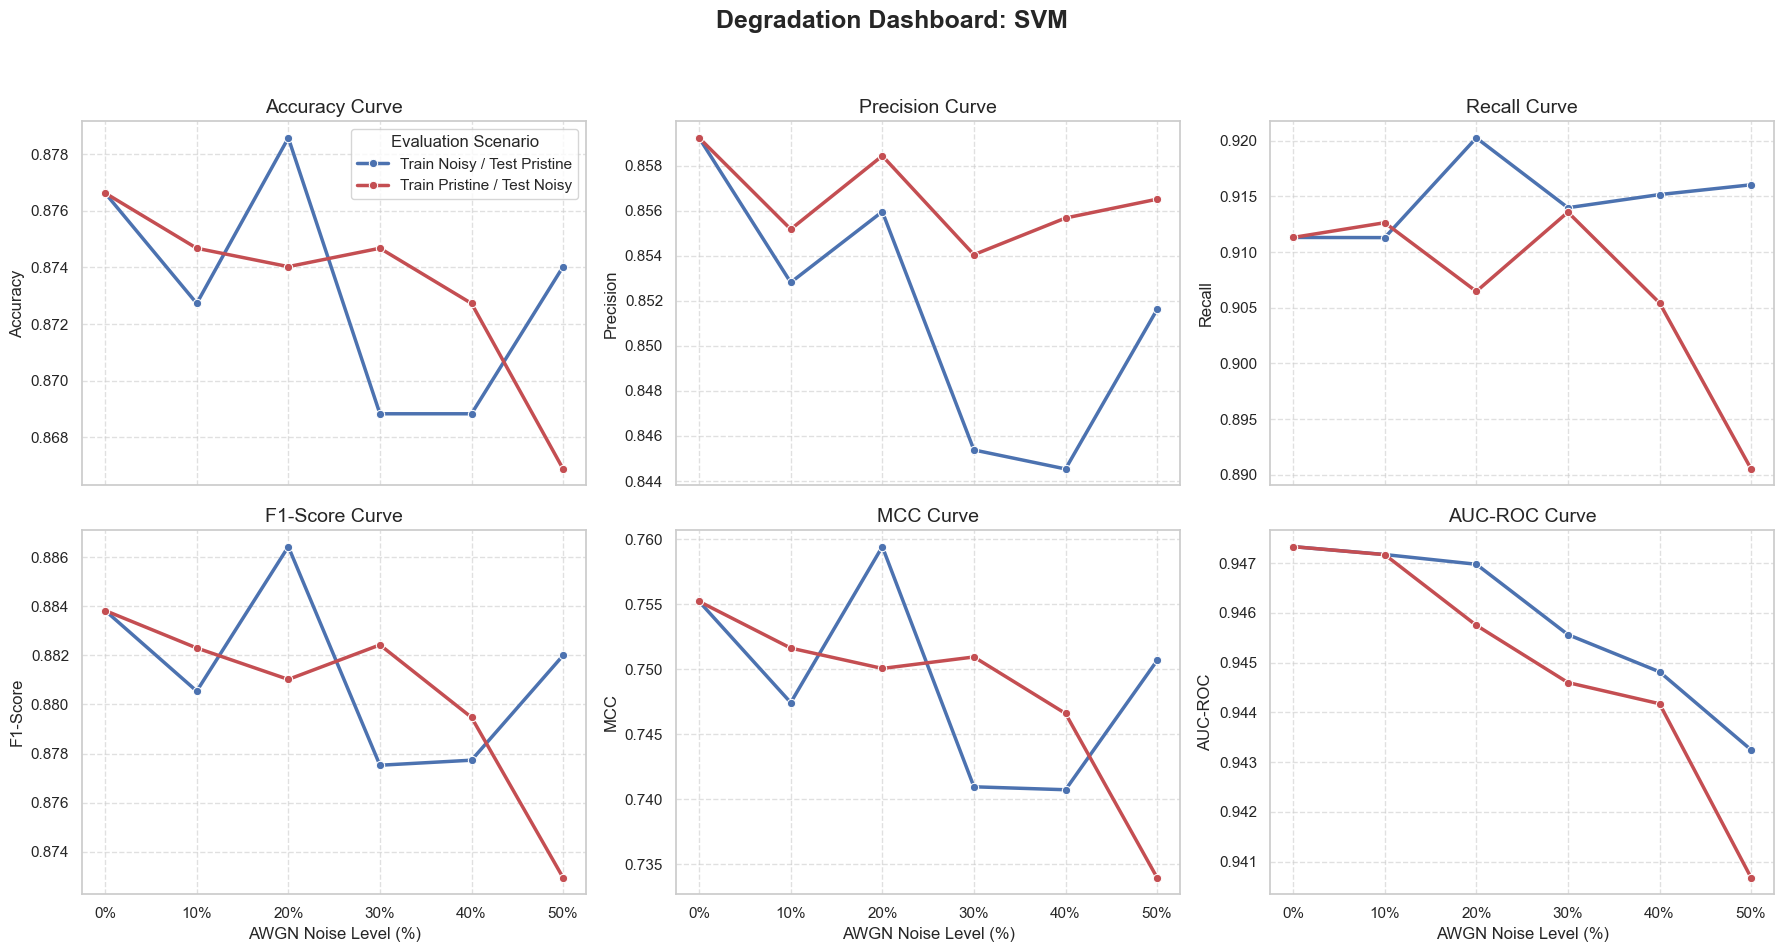

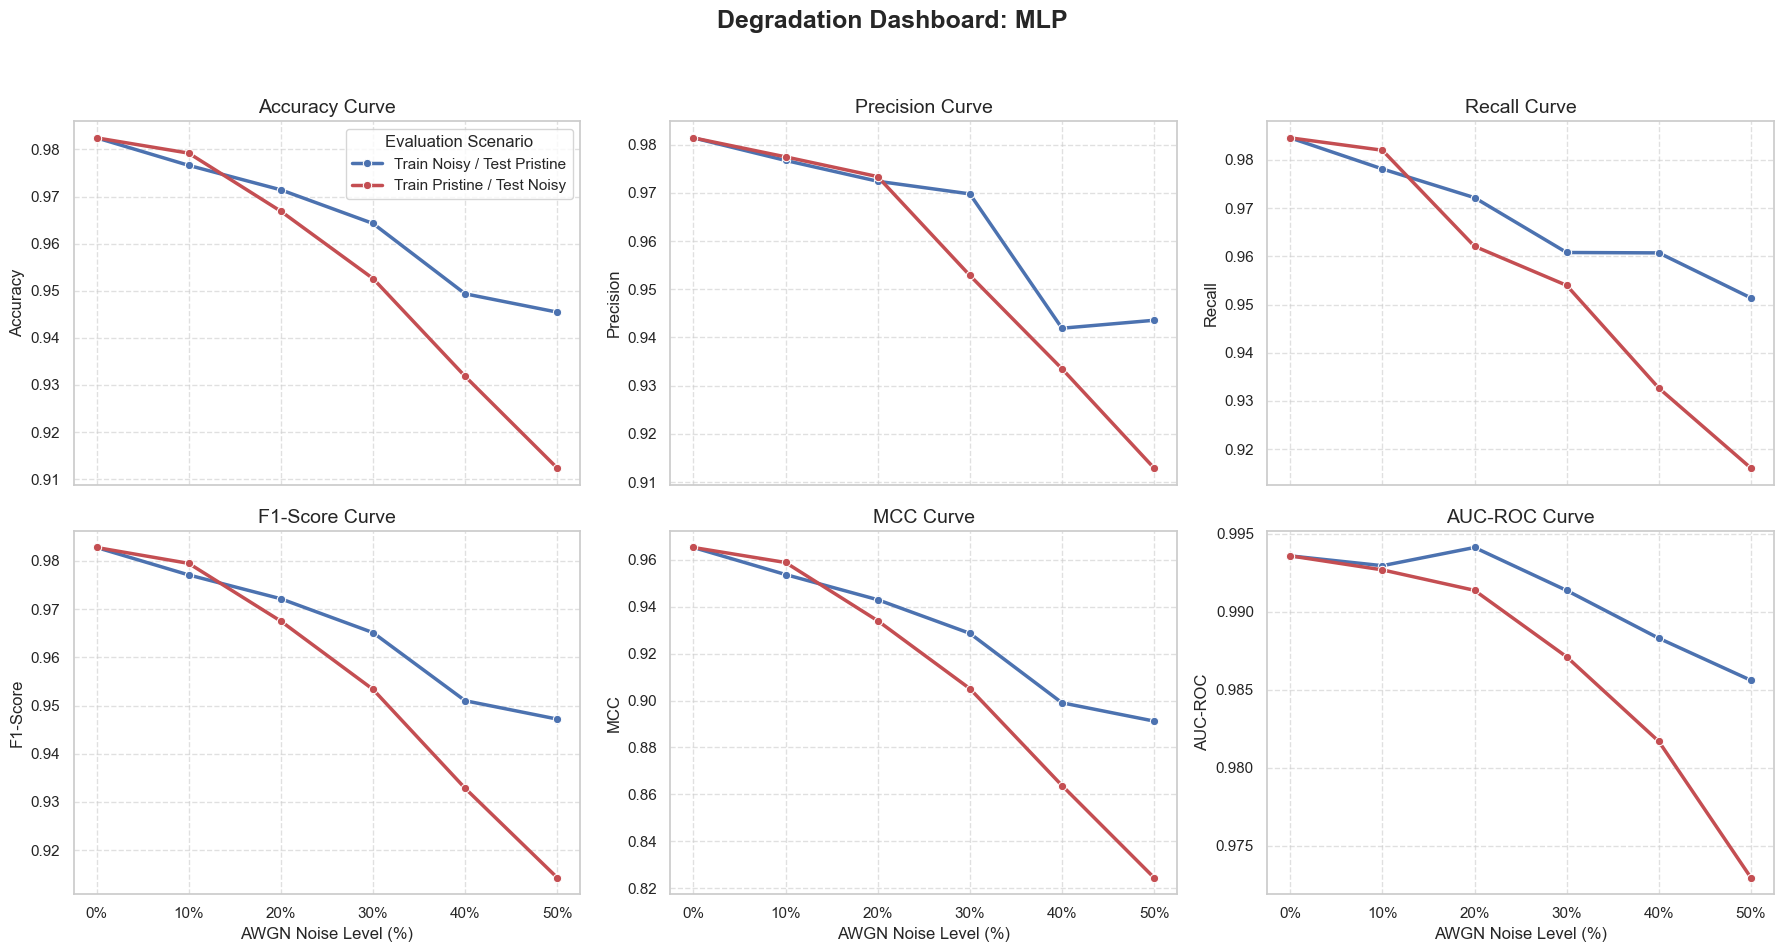

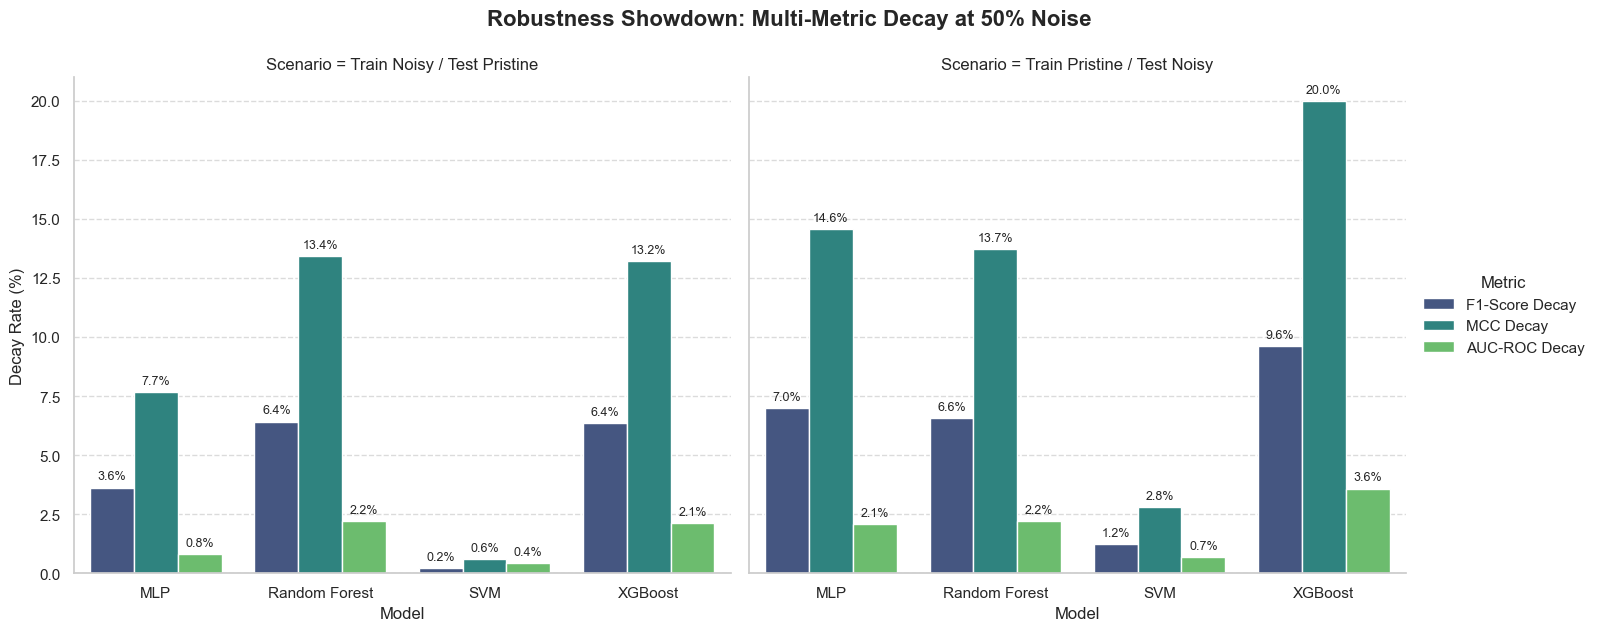

In [32]:
# ---------------------------------------------------------
# VISUALIZATION 1: Comprehensive Metric Dashboard per Model
# ---------------------------------------------------------
def plot_metric_dashboard(df, model_name):
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 'AUC-ROC']
    model_data = df[df['Model'] == model_name]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
    fig.suptitle(f'Degradation Dashboard: {model_name}', fontsize=18, fontweight='bold')
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        sns.lineplot(data=model_data, x='Noise Level', y=metric, hue='Scenario', 
                     marker='o', linewidth=2.5, ax=axes[idx], palette=['#4c72b0', '#c44e52'])
        
        axes[idx].set_title(f'{metric} Curve', fontsize=14)
        axes[idx].set_xlabel('AWGN Noise Level (%)' if idx >= 3 else '', fontsize=12)
        axes[idx].set_ylabel(metric, fontsize=12)
        axes[idx].set_xticks(model_data['Noise Level'].unique())
        axes[idx].set_xticklabels([f"{n}%" for n in model_data['Noise Level'].unique()])
        axes[idx].grid(True, linestyle='--', alpha=0.6)
        
        if idx == 0:
            axes[idx].legend(title="Evaluation Scenario", loc='best')
        else:
            if axes[idx].get_legend() is not None:
                axes[idx].get_legend().remove()
                
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ---------------------------------------------------------
# VISUALIZATION 2: Model Robustness Comparison (3-Metric Decay)
# ---------------------------------------------------------
def plot_decay_comparison(df):
    max_noise = df['Noise Level'].max()
    decay_data = df[df['Noise Level'] == max_noise]
    
    # Restructure data specifically for seaborn's grouped plotting
    melted_decay = pd.melt(decay_data, 
                           id_vars=['Model', 'Scenario'], 
                           value_vars=['Decay Rate (F1) (%)', 'Decay Rate (MCC) (%)', 'Decay Rate (AUC-ROC) (%)'],
                           var_name='Metric', value_name='Decay Rate (%)')
    
    # Clean names for the chart legend
    metric_map = {
        'Decay Rate (F1) (%)': 'F1-Score Decay',
        'Decay Rate (MCC) (%)': 'MCC Decay',
        'Decay Rate (AUC-ROC) (%)': 'AUC-ROC Decay'
    }
    melted_decay['Metric'] = melted_decay['Metric'].map(metric_map)
    
    # Create side-by-side faceted bar charts
    g = sns.catplot(data=melted_decay, kind='bar', x='Model', y='Decay Rate (%)', 
                    hue='Metric', col='Scenario', palette='viridis', height=6, aspect=1.2)
    
    g.fig.suptitle(f'Robustness Showdown: Multi-Metric Decay at {int(max_noise)}% Noise', fontsize=16, fontweight='bold', y=1.05)
    
    # Add value annotations on top of the bars
    for ax in g.axes.flat:
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f"{p.get_height():.1f}%", 
                            (p.get_x() + p.get_width() / 2., p.get_height()), 
                            ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=9)
                
    plt.show()

# --- Execution ---
print("Generating Dashboards...")

for model in models.keys():
    plot_metric_dashboard(agg_results, model)

plot_decay_comparison(agg_results)